# Main scan: calibrated data products (sections 5, 6, 6b)

Combines the per-pol dimensionless ratios $R_{\rm pol}(v_{\rm LSR})$
from `main_scan_load.ipynb` (state in `artifacts/scan_load_state.pkl`)
with the EBHIS-anchored, 24 h PDT Fourier $T_{\rm cal}^{\rm pol}(t)$
model from `main_scan_calibration.ipynb` (state in
`artifacts/tcal_drift_state.pkl`) to produce the calibrated
(temperature-units) analogues of the load notebook's sections 5, 6,
and 6b:

| Section | Product | Units |
|---|---|---|
| 5  | per-cell scatter Mollweide of $W = \int T_B\,dv$ | K km/s |
| 6  | beam-weighted gridded Mollweide of $W$ | K km/s |
| 6b | beam-weighted $\ell$-$v$ strip $T_B(\ell, v)$ at $b \sim 0$ | K |

These are the temperature-calibrated counterparts of the $R$-space
maps plotted in `main_scan_load.ipynb`; the calibration step here is
the same as that used by `main_scan_qa.ipynb`. The integrated map can
be read directly as a column density via the optically-thin relation
$N_{\rm HI} = 1.823\times 10^{18}\, W\ {\rm cm}^{-2}$.

Pipeline order:

1. Load `cell_combined`, `viable_pairs_per_cell`, `cell_scalars`, and
   the LSR axis from `scan_load_state.pkl`.
2. Load the per-pol PDT Fourier coefficients from
   `tcal_drift_state.pkl` and evaluate $T_{\rm cal}^{\rm pol}(t)$ at
   each `(session, cell)` median observation time.
3. Per-pol per-LO cool-method $T_{\rm sys}^{\rm pol}(t) = T_{\rm cal}^{\rm pol}(t)\,\langle P_{\rm off}\rangle / \langle P_{\rm on} - P_{\rm off}\rangle$,
   averaged across the two LOs, then pair-count-weighted across sessions
   to a per-cell $T_{\rm sys}^{\rm pol}$.
4. $T_B^{\rm pol}(v) = R^{\rm pol}(v)\,T_{\rm sys}^{\rm pol}$;
   Stokes-I $T_B = T_B^{\rm pol 0} + T_B^{\rm pol 1}$.
5. Build the three data products from the calibrated `T_B` and persist
   to `artifacts/scan_data_products.pkl`.

In [16]:
from collections import defaultdict
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt

from utils import (
    assemble_W_R_arrays,
    compute_lv_strip,
)
from plotters import (
    plot_survey_mollweide,
    plot_survey_mollweide_gridded,
    plot_lv_strip,
)
from ugradiolab.plotting import SS_MICRO, SS_FINE

# --- Hardware / display ---
HPBW_DEG = 3.4
MOLL_CENTER_L = 120.0

# --- Y-factor floor for per-LO T_sys (mirror main_scan_qa.ipynb) ---
Y_MIN = 1.01

# --- Cross-pol consistency demotion (mirror main_scan_qa.ipynb sec. 2c) ---
# Pol 0's noise diode at LO 1419.86 MHz often fails to inject above
# noise; cells whose pol-0 vs pol-1 brightness disagrees in the signal
# window are demoted to single-pol Stokes I.
POL_SIGNAL_V_LO_KMS = -80.0
POL_SIGNAL_V_HI_KMS =  60.0
POL_DISAGREE_FRAC   = 0.10   # median |T_B_pol0 - T_B_pol1| / median(0.5*(pol0+pol1))
POL_AVG_FLOOR_K     = 5.0    # noise floor for the denominator in K
POL_MIN_VALID_CH    = 8      # need at least this many finite channels in signal window

# --- Section 6 / 6b sampling ---
PIXEL_DEG = 0.5      # Mollweide pixel size for the gridded map
CUTOFF_HPBW = 2.0    # Gaussian-kernel hard truncation in HPBW units
LV_DL_FINE = 0.5     # longitude pixel for the l-v strip (deg)
B_MAX_DEG = 4.0      # cells within |b| <= this contribute to the b ~ 0 strip

# --- Optically-thin HI column-density coefficient ---
NH_TO_TBKMS = 1.823e18  # cm^-2 per (K km/s)

# --- Paths ---
STATE_PATH = Path('artifacts/scan_load_state.pkl')
TCAL_DRIFT_PATH = Path('artifacts/tcal_drift_state.pkl')
PRODUCTS_PATH = Path('artifacts/scan_data_products.pkl')

get_ipython().run_line_magic('matplotlib', 'inline')

## 1. Load state from `main_scan_load.ipynb` and `main_scan_calibration.ipynb`

In [17]:
with open(STATE_PATH, 'rb') as f:
    state = pickle.load(f)

cell_combined = state['cell_combined']
viable_pairs_per_cell = state['viable_pairs_per_cell']
cells_insufficient_pairs = state['cells_insufficient_pairs']
v_lsr_overlap = state['v_lsr_overlap']
dv_kms = state['dv_kms']
sessions = state['sessions']
cell_scalars = state['cell_scalars']
F1_MHZ, F2_MHZ = state['lo_pair_mhz']

print(f'Loaded {STATE_PATH} ({STATE_PATH.stat().st_size/1e6:.2f} MB)')
print(f'  {len(cell_combined)} science cells, '
      f'{len(cells_insufficient_pairs)} insufficient-pair cells')
print(f'  dv = {dv_kms:.3f} km/s, v_LSR span '
      f'[{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s, '
      f'{len(sessions)} sessions')
print(f'  {len(cell_scalars)} per-(session, cell) calibration scalars')

with open(TCAL_DRIFT_PATH, 'rb') as f:
    drift_state = pickle.load(f)

PERIOD_H  = float(drift_state['period_hours'])
TZ_OFFSET = float(drift_state['tz_offset_hours'])
N_HARM    = {int(k): int(v) for k, v in drift_state['n_harmonics'].items()}
T_MIN_FIT = float(drift_state['t_min'])
T_MAX_FIT = float(drift_state['t_max'])
TCAL_COEF = {pi: np.asarray(drift_state['fit'][pi]['coef'], dtype=float)
             for pi in (0, 1)}

print(f"Loaded {TCAL_DRIFT_PATH}: pointing={drift_state['pointing']}, "
      f"K_0={N_HARM[0]}, K_1={N_HARM[1]}, "
      f"N_pol0={drift_state['fit'][0]['N']}, "
      f"N_pol1={drift_state['fit'][1]['N']}, "
      f"period={PERIOD_H:.1f} h, tz_offset={TZ_OFFSET:+.1f} h")

Loaded artifacts/scan_load_state.pkl (109.40 MB)
  2652 science cells, 0 insufficient-pair cells
  dv = 0.660 km/s, v_LSR span [-164, 132] km/s, 64 sessions
  2709 per-(session, cell) calibration scalars
Loaded artifacts/tcal_drift_state.pkl: pointing=recal_drift_bk, K_0=2, K_1=1, N_pol0=192, N_pol1=192, period=24.0 h, tz_offset=-7.0 h


## 2. Temperature calibration: $T_B$ from per-pol PDT Fourier $T_{\rm cal}(t)$

Mirrors the calibration block of `main_scan_qa.ipynb`. The 24 h PDT
Fourier model from `main_scan_calibration.ipynb` is

$$
T_{\rm cal}^{\rm pol}(h_{\rm PDT})\;=\;a_0\;+\;\sum_{k=1}^{K_{\rm pol}}
\bigl[a_k\cos(2\pi k h/24) + b_k\sin(2\pi k h/24)\bigr],
$$

with $K_0 = 2$ and $K_1 = 1$ harmonics solved at the (90, 72) recal
pointing. For each cell `(gl, gb)`:

1. Look up the cached `t_median` and per-(pol, LO) $P_{\rm on}$ /
   $P_{\rm off}$ from `cell_scalars` for every session that observed
   the cell.
2. Fold $t_{\rm median} \to h_{\rm PDT}$ and evaluate the Fourier model
   per pol.
3. Cool-method per pol per LO: $T_{\rm sys}^{\rm pol, LO} =
   T_{\rm cal}^{\rm pol}(t)\, P_{\rm off} / (P_{\rm on} - P_{\rm off})$,
   averaged across the two LOs.  A Y-factor floor $P_{\rm on}/P_{\rm off}
   \geq Y_{\rm min} = 1.01$ rejects LO entries where the noise diode
   fails to inject above noise (mainly pol 0 at LO 1419.86 MHz).
4. Per-cell $T_{\rm sys}^{\rm pol}$ is the pair-count-weighted mean of
   $T_{\rm sys}^{\rm pol}({\rm session})$ across the sessions that
   contributed pairs to that cell.
5. $T_B^{\rm pol}(v) = R^{\rm pol}(v)\,T_{\rm sys}^{\rm pol}$;
   Stokes-I $T_B = T_B^{\rm pol 0} + T_B^{\rm pol 1}$.

Cells whose `t_median` lies outside the fit window
`[t_min_fit, t_max_fit]` are marked `extrapolated` (the Fourier model
is periodic, so values stay bounded, but flag them so downstream
consumers can warn).

In [18]:
def _hour_pdt(unix_t, tz_offset=TZ_OFFSET):
    return ((np.asarray(unix_t, dtype=float) / 3600.0) + tz_offset) % 24.0


def _fourier_design(h, K, period=PERIOD_H):
    h = np.atleast_1d(np.asarray(h, dtype=float))
    cols = [np.ones_like(h)]
    for k in range(1, K + 1):
        omega = 2.0 * np.pi * k / period
        cols.append(np.cos(omega * h))
        cols.append(np.sin(omega * h))
    return np.column_stack(cols)


def eval_tcal_pol(unix_t, pi):
    h = _hour_pdt(unix_t)
    X = _fourier_design(h, N_HARM[pi])
    val = X @ TCAL_COEF[pi]
    return float(val[0]) if np.isscalar(unix_t) else val


n_lo_rejected = {(pi, lo): 0 for pi in (0, 1) for lo in (F1_MHZ, F2_MHZ)}


def session_cell_tsys_per_pol(sess, gl, gb):
    entry = cell_scalars.get((sess, gl, gb))
    if entry is None:
        return {0: np.nan, 1: np.nan}, False, np.nan
    t = float(entry['t_median'])
    extrap = (t < T_MIN_FIT) or (t > T_MAX_FIT)
    out = {}
    for pi in (0, 1):
        Tcal = eval_tcal_pol(t, pi)
        if not np.isfinite(Tcal):
            out[pi] = np.nan
            continue
        per_lo = []
        for lo in (F1_MHZ, F2_MHZ):
            P_on  = entry.get(f'P_on_pol{pi}_{lo:g}',  np.nan)
            P_off = entry.get(f'P_off_pol{pi}_{lo:g}', np.nan)
            if not (np.isfinite(P_on) and np.isfinite(P_off)):
                continue
            if P_off <= 0:
                continue
            dP = P_on - P_off
            if dP <= 0:
                continue
            if (P_on / P_off) < Y_MIN:
                n_lo_rejected[(pi, lo)] += 1
                continue
            per_lo.append(Tcal * P_off / dP)
        out[pi] = float(np.mean(per_lo)) if per_lo else np.nan
    return out, extrap, t


n_calibrated = 0
n_no_tsys    = 0
n_extrap     = 0
tsys_summary = {0: [], 1: []}

for (gl, gb), pairs in viable_pairs_per_cell.items():
    sess_counts = defaultdict(int)
    for pr in pairs:
        sess_counts[pr['session']] += 1

    num = {0: 0.0, 1: 0.0}
    den = {0: 0.0, 1: 0.0}
    any_extrap = False
    for sess, n_pr in sess_counts.items():
        tsys_dict, extrap, _ = session_cell_tsys_per_pol(sess, gl, gb)
        for pi in (0, 1):
            if np.isfinite(tsys_dict[pi]):
                num[pi] += tsys_dict[pi] * n_pr
                den[pi] += n_pr
        if extrap:
            any_extrap = True

    entry = cell_combined[(gl, gb)]
    for pi in (0, 1):
        if den[pi] > 0:
            T_sys_cell = num[pi] / den[pi]
            entry[f'T_sys_pol{pi}'] = float(T_sys_cell)
            entry[f'T_B_pol{pi}']   = entry[f'R_pol{pi}'] * T_sys_cell
            tsys_summary[pi].append(T_sys_cell)
        else:
            entry[f'T_sys_pol{pi}'] = np.nan
            entry[f'T_B_pol{pi}']   = np.full_like(entry[f'R_pol{pi}'], np.nan)

    if np.isfinite(entry.get('T_sys_pol0', np.nan)) and \
       np.isfinite(entry.get('T_sys_pol1', np.nan)):
        entry['T_B'] = entry['T_B_pol0'] + entry['T_B_pol1']
        n_calibrated += 1
    else:
        entry['T_B'] = np.full_like(entry['R_pol0'], np.nan)
        n_no_tsys += 1
    entry['extrapolated'] = bool(any_extrap)
    if any_extrap:
        n_extrap += 1

print(f'T_B calibration: {n_calibrated} cells fully calibrated (both pols), '
      f'{n_no_tsys} with at least one pol missing T_sys, '
      f'{n_extrap} flagged extrapolated')
print(f'Y-factor floor (Y_MIN={Y_MIN}) per-LO rejections:')
for (pi, lo), n in n_lo_rejected.items():
    print(f'  pol {pi} LO {lo:g} MHz: {n} entries rejected')
for pi in (0, 1):
    arr = np.array(tsys_summary[pi])
    if arr.size:
        print(f'  pol {pi} T_sys: median={np.median(arr):.1f} K, '
              f'IQR [{np.percentile(arr, 25):.1f}, '
              f'{np.percentile(arr, 75):.1f}] K, '
              f'range [{arr.min():.1f}, {arr.max():.1f}] K  (N={arr.size})')

T_B calibration: 2572 cells fully calibrated (both pols), 80 with at least one pol missing T_sys, 54 flagged extrapolated
Y-factor floor (Y_MIN=1.01) per-LO rejections:
  pol 0 LO 1419.86 MHz: 511 entries rejected
  pol 0 LO 1421.14 MHz: 82 entries rejected
  pol 1 LO 1419.86 MHz: 0 entries rejected
  pol 1 LO 1421.14 MHz: 0 entries rejected
  pol 0 T_sys: median=108.3 K, IQR [81.5, 135.9] K, range [21.6, 270.2] K  (N=2572)
  pol 1 T_sys: median=93.6 K, IQR [83.2, 103.6] K, range [59.1, 151.9] K  (N=2652)


## 2b. Cross-polarisation consistency demotion

Mirrors section 2c of `main_scan_qa.ipynb`. For unpolarised HI the
two linear pols should report identical brightness temperatures up to
noise:

$$
T_{B,\rm pol0}(v_{\rm LSR})\;\approx\;T_{B,\rm pol1}(v_{\rm LSR})\;
\approx\;\tfrac{1}{2}\,T_B^{\rm Stokes\,I}(v_{\rm LSR}).
$$

Pol 0's noise diode at LO 1419.86 MHz often fails to inject
appreciably above noise (the Y-factor floor catches the worst entries
but marginal cases slip through, giving an unphysical low
$T_{\rm sys}^{\rm pol0}$ and hence a biased $T_B^{\rm pol0}$). Without
this demotion, cells where pol-0 is contaminated mix into Stokes I and
appear as jump discontinuities against neighbours observed in a
different session / LO mix.

Procedure:

1. For each cell, compute over the signal window
   $[v_{\rm lo}, v_{\rm hi}] = [-80, +60]$ km/s:

   ```
   diff = median |T_B_pol0(v) - T_B_pol1(v)|
   avg  = median 0.5 * (T_B_pol0(v) + T_B_pol1(v))
   pol_disagree_frac = diff / max(avg, POL_AVG_FLOOR_K)
   ```

2. If `pol_disagree_frac > POL_DISAGREE_FRAC = 0.10`, demote the cell
   to single-pol Stokes I:

   ```
   bad  = argmax(T_sys_pol)           # noisier diode -> bigger T_sys
   good = 1 - bad
   T_B  = 2 * T_B_pol{good}            # factor 2 restores Stokes-I scale
   ```

3. SNR cost: demoted cells lose a factor of sqrt(2) in sensitivity.
   This is logged but not propagated as a per-cell uncertainty.

In [19]:
pol_sig_mask = (v_lsr_overlap >= POL_SIGNAL_V_LO_KMS) & \
               (v_lsr_overlap <= POL_SIGNAL_V_HI_KMS)

n_demoted = {0: 0, 1: 0}
n_evaluated = 0
disagree_fracs = []

for (gl, gb), entry in cell_combined.items():
    entry['pol_demoted'] = None
    entry['pol_disagree_frac'] = np.nan

    tb0 = entry.get('T_B_pol0')
    tb1 = entry.get('T_B_pol1')
    if tb0 is None or tb1 is None:
        continue
    tb0 = np.asarray(tb0); tb1 = np.asarray(tb1)
    finite = np.isfinite(tb0) & np.isfinite(tb1) & pol_sig_mask
    if finite.sum() < POL_MIN_VALID_CH:
        continue

    diff = np.abs(tb0[finite] - tb1[finite])
    avg  = 0.5 * (tb0[finite] + tb1[finite])
    med_diff = float(np.median(diff))
    med_avg  = float(np.median(avg))
    frac = med_diff / max(med_avg, POL_AVG_FLOOR_K)

    entry['pol_disagree_frac'] = frac
    disagree_fracs.append(frac)
    n_evaluated += 1

    if frac > POL_DISAGREE_FRAC:
        ts0 = entry.get('T_sys_pol0', np.nan)
        ts1 = entry.get('T_sys_pol1', np.nan)
        if np.isfinite(ts0) and np.isfinite(ts1):
            bad = 0 if ts0 > ts1 else 1
        elif np.isfinite(ts0):
            bad = 1
        else:
            bad = 0
        good = 1 - bad
        entry['T_B'] = 2.0 * entry[f'T_B_pol{good}']
        entry['pol_demoted'] = bad
        n_demoted[bad] += 1

# Single-pol rescue: cells with only one valid pol (other pol NaN from
# Y_MIN / missing P_on/off) currently have T_B = NaN.  Promote them to
# 2 * T_B_pol_good so they appear in the maps rather than dropping out.
n_rescued = 0
for (gl, gb), entry in cell_combined.items():
    if np.all(np.isfinite(entry['T_B'])):
        continue
    ts0 = entry.get('T_sys_pol0', np.nan)
    ts1 = entry.get('T_sys_pol1', np.nan)
    have0 = np.isfinite(ts0)
    have1 = np.isfinite(ts1)
    if have0 and not have1:
        entry['T_B'] = 2.0 * entry['T_B_pol0']
        entry['pol_demoted'] = 1
        n_rescued += 1
    elif have1 and not have0:
        entry['T_B'] = 2.0 * entry['T_B_pol1']
        entry['pol_demoted'] = 0
        n_rescued += 1

print(f'Cross-pol consistency: {n_evaluated} cells evaluated '
      f'(signal window [{POL_SIGNAL_V_LO_KMS:.0f}, {POL_SIGNAL_V_HI_KMS:.0f}] km/s)')
if disagree_fracs:
    arr = np.array(disagree_fracs)
    print(f'  pol_disagree_frac: median={np.median(arr):.3f}, '
          f'IQR [{np.percentile(arr, 25):.3f}, {np.percentile(arr, 75):.3f}], '
          f'max={arr.max():.3f}')
print(f'  Demoted (frac > {POL_DISAGREE_FRAC}): '
      f'pol-0 dropped in {n_demoted[0]} cells, '
      f'pol-1 dropped in {n_demoted[1]} cells')
print(f'  Single-pol rescued (other pol missing T_sys): {n_rescued} cells')

n_valid_after = sum(1 for e in cell_combined.values()
                    if np.any(np.isfinite(e['T_B'])))
print(f'  cells with finite T_B after demotion / rescue: {n_valid_after}')

Cross-pol consistency: 2572 cells evaluated (signal window [-80, 60] km/s)
  pol_disagree_frac: median=0.222, IQR [0.157, 0.297], max=0.870
  Demoted (frac > 0.1): pol-0 dropped in 1652 cells, pol-1 dropped in 772 cells
  Single-pol rescued (other pol missing T_sys): 80 cells
  cells with finite T_B after demotion / rescue: 2652


## 5. Integrated brightness map $W(\ell, b)$

Calibrated counterpart of section 5 of `main_scan_load.ipynb`. The
per-cell velocity-integrated Stokes-I brightness temperature

$$
W(\ell, b)\;=\;\int T_B(\ell, b, v_{\rm LSR})\,dv_{\rm LSR}\;
\approx\;\Delta v\sum_j T_{B,j}\quad [\mathrm{K\,km\,s^{-1}}]
$$

translates directly into an optically-thin neutral-hydrogen column
density via $N_{\rm HI} = 1.823\times 10^{18}\,W\ {\rm cm}^{-2}$. The
Mollweide projection (equal area, centred on $\ell_0 = 120^\circ$) is
shared with the load notebook so the calibrated map can be compared
directly to its $W_R$ analogue. Cells with missing $T_{\rm sys}$ on
either pol have NaN $T_B$ and drop out of the map.

T_B-calibrated cells with finite W: 2652 of 2652
  W (K km/s): median=1638, IQR [870, 2610], range [-199, 9736]
  N_HI (cm^-2): median=2.99e+21, max=1.77e+22


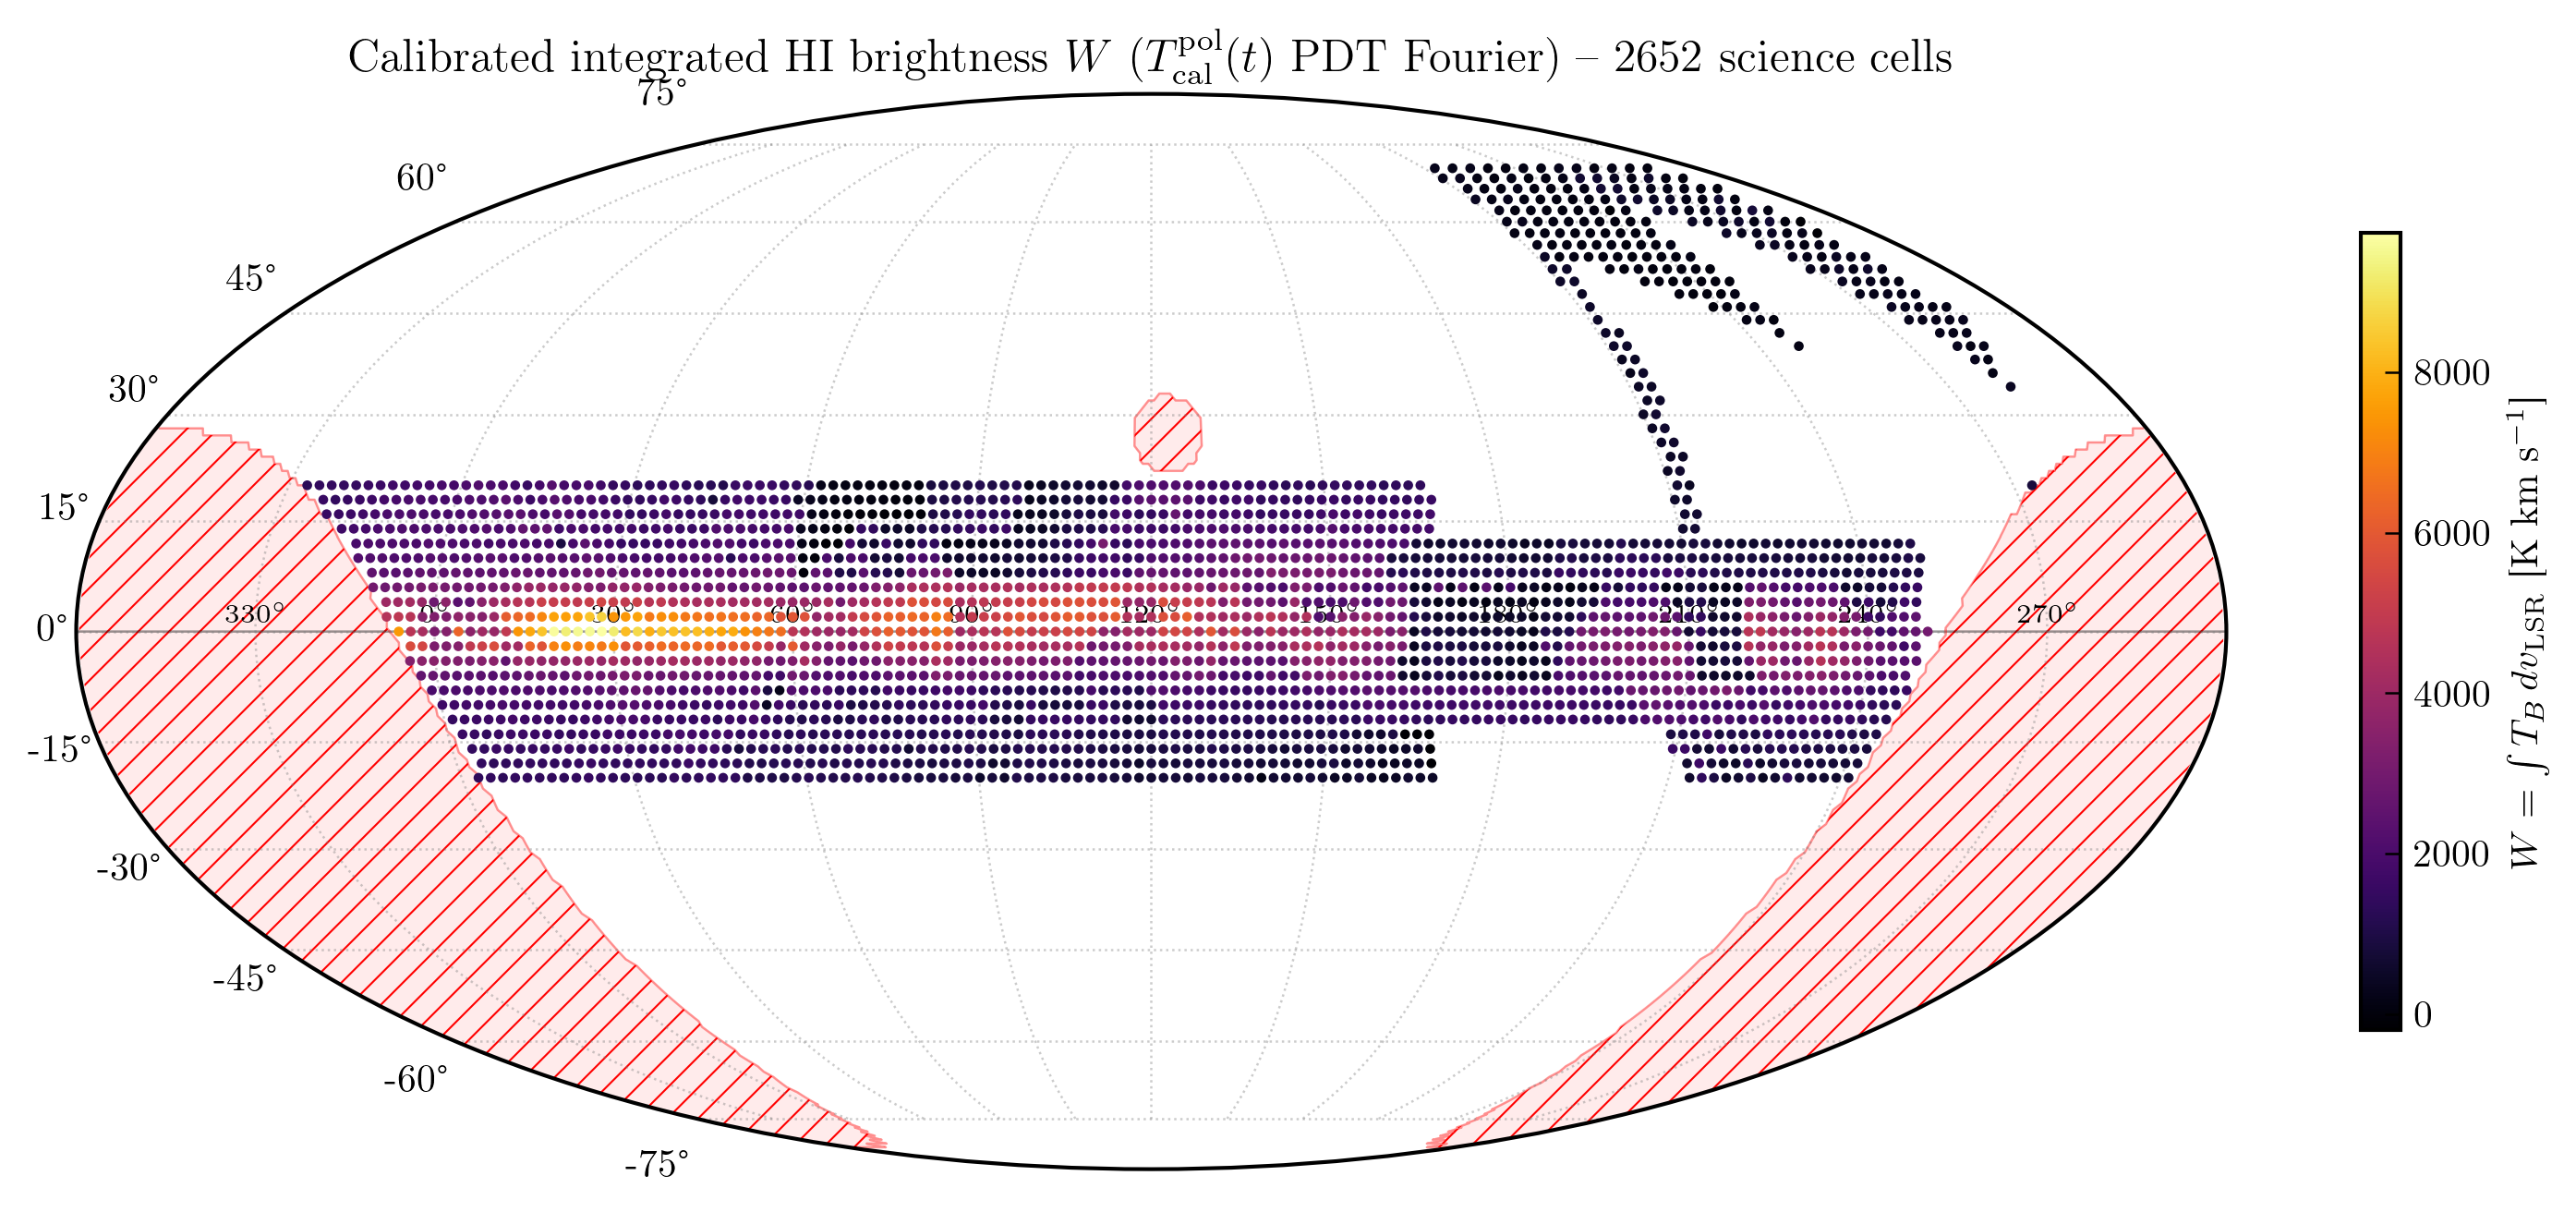

In [20]:
arrs = assemble_W_R_arrays(cell_combined, dv_kms, spectrum_key='T_B')
gl_arr = arrs['gl']; gb_arr = arrs['gb']
W_TB   = arrs['W_R']; valid  = arrs['valid']

print(f'T_B-calibrated cells with finite W: {arrs["n_sci"]} of {len(cell_combined)}')
if valid.any():
    finite_W = W_TB[valid]
    print(f'  W (K km/s): median={np.median(finite_W):.0f}, '
          f'IQR [{np.percentile(finite_W, 25):.0f}, '
          f'{np.percentile(finite_W, 75):.0f}], '
          f'range [{finite_W.min():.0f}, {finite_W.max():.0f}]')
    print(f'  N_HI (cm^-2): median={NH_TO_TBKMS * np.median(finite_W):.2e}, '
          f'max={NH_TO_TBKMS * finite_W.max():.2e}')

fig, ax = plot_survey_mollweide(
    gl_arr[valid], gb_arr[valid], W_TB[valid],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W = \int T_B\, dv_{\rm LSR}$ [K km s$^{-1}$]',
    cmap='inferno',
    marker_size=(SS_FINE + SS_MICRO) / 2,
    title=(f'Calibrated integrated HI brightness $W$ '
           f'($T_{{\\rm cal}}^{{\\rm pol}}(t)$ PDT Fourier) -- '
           f'{arrs["n_sci"]} science cells'),
)
plt.show()

## 6. Beam-weighted Mollweide map of $W$

Calibrated counterpart of section 6 of `main_scan_load.ipynb`. The
scatter samples above are regridded under the dish Gaussian beam onto
a fine pixel grid using
`plotters.plot_survey_mollweide_gridded`:

1. deposit each pointing onto its nearest pixel in the local sinusoidal
   projection $u = (\ell - \ell_0)\cos b,\, v = b$ (value- and
   weight-grids),
2. FFT-convolve both grids with the 2-D Gaussian of
   FWHM $= \theta_{\rm HPBW} = 3.4^\circ$, truncated at
   `cutoff_hpbw * HPBW`,
3. sample back onto the Mollweide $(\ell, b)$ grid and divide
   numerator by denominator where the total weight exceeds
   `min_weight`.

Pixels with no nearby pointings have zero denominator and render as
transparent NaN, so the never-observable wedge appears as a hatched
overlay without explicit segment bookkeeping.

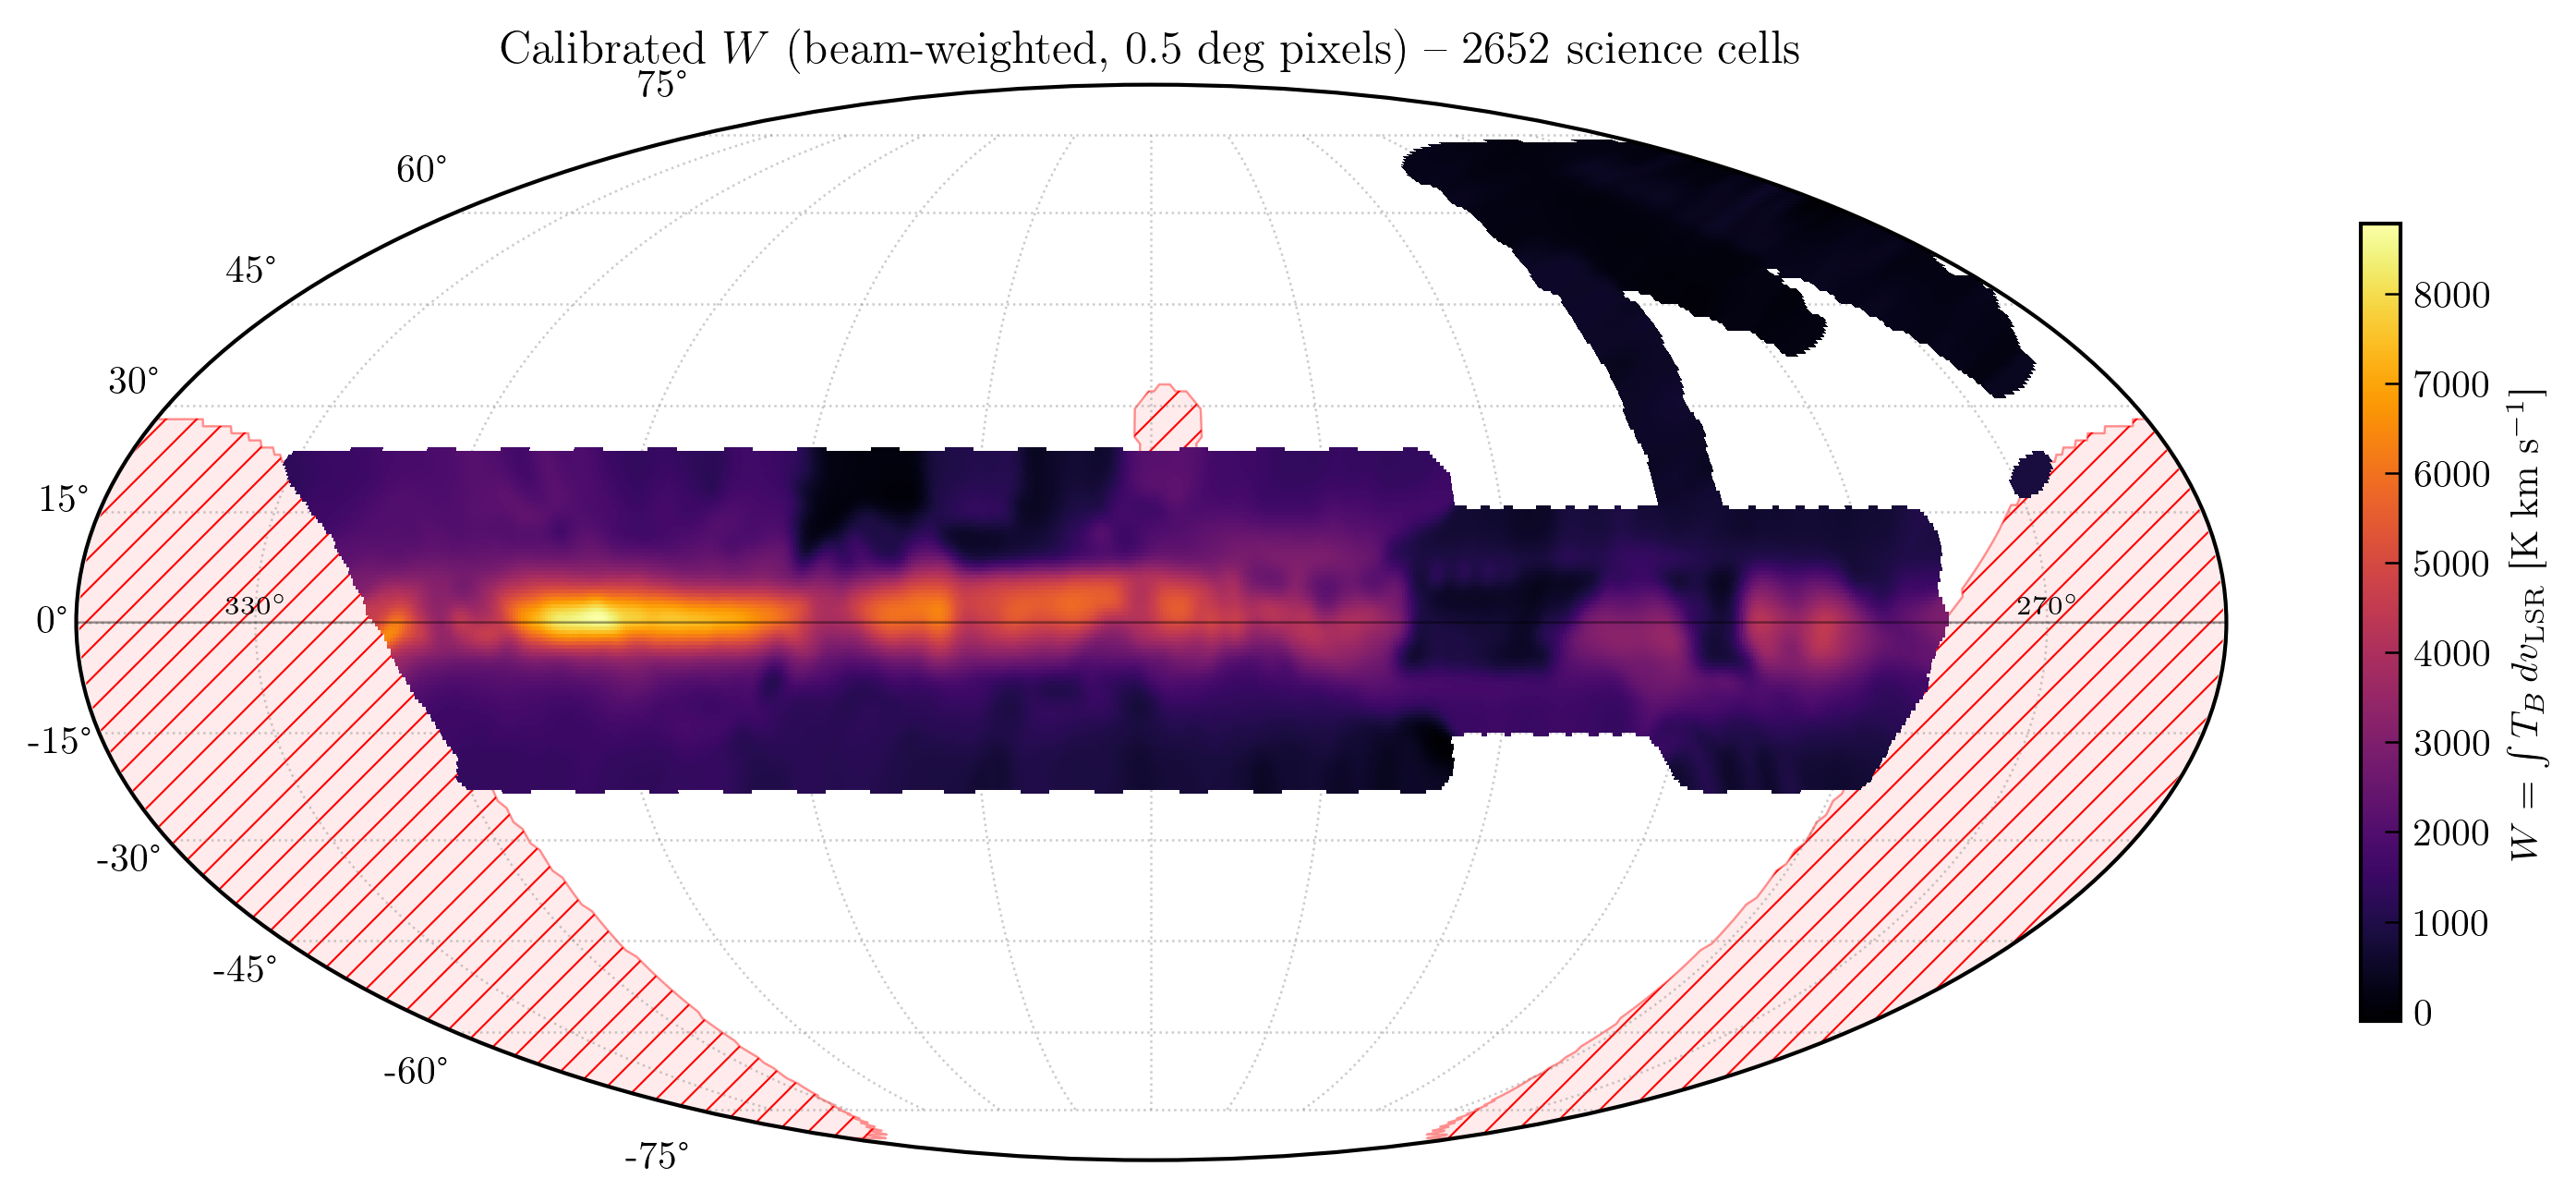

In [21]:
fig, ax = plot_survey_mollweide_gridded(
    gl_arr[valid], gb_arr[valid], W_TB[valid],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W = \int T_B\, dv_{\rm LSR}$ [K km s$^{-1}$]',
    cmap='inferno',
    hpbw_deg=HPBW_DEG,
    pixel_deg=PIXEL_DEG,
    cutoff_hpbw=CUTOFF_HPBW,
    title=(f'Calibrated $W$ (beam-weighted, {PIXEL_DEG} deg pixels) -- '
           f'{arrs["n_sci"]} science cells'),
)
plt.show()

## 6b. Beam-weighted $\ell$-$v$ strip $T_B(\ell, v)$ at $b \sim 0$

Calibrated counterpart of section 6b of `main_scan_load.ipynb`. Cells
with $|b| \leq b_{\max}$ contribute to a fine longitude grid via the
great-circle Gaussian-beam weight
$w_p(\ell) = \exp[-\tfrac12(\theta_p / \sigma)^2]$ with
$\sigma = \theta_{\rm HPBW} / 2.355$, hard-truncated at
`cutoff_hpbw * HPBW`. The strip pixel is the weighted mean of all
contributing cells' $T_B(v)$ spectra. Pixels whose total weight falls
below `min_weight`, or where no cell lies within `keep_near_hpbw *
HPBW`, are masked. The upper envelope of the resulting $T_B(\ell, v)$
image is the standard input to the tangent-point rotation-curve fit
(Lab manual sec. 7).

`cells_insufficient_pairs` (cells with fewer than
`MIN_VIABLE_PAIRS = 3` surviving pairs) are excluded so the strip is
not biased by noisy under-integrated sightlines.

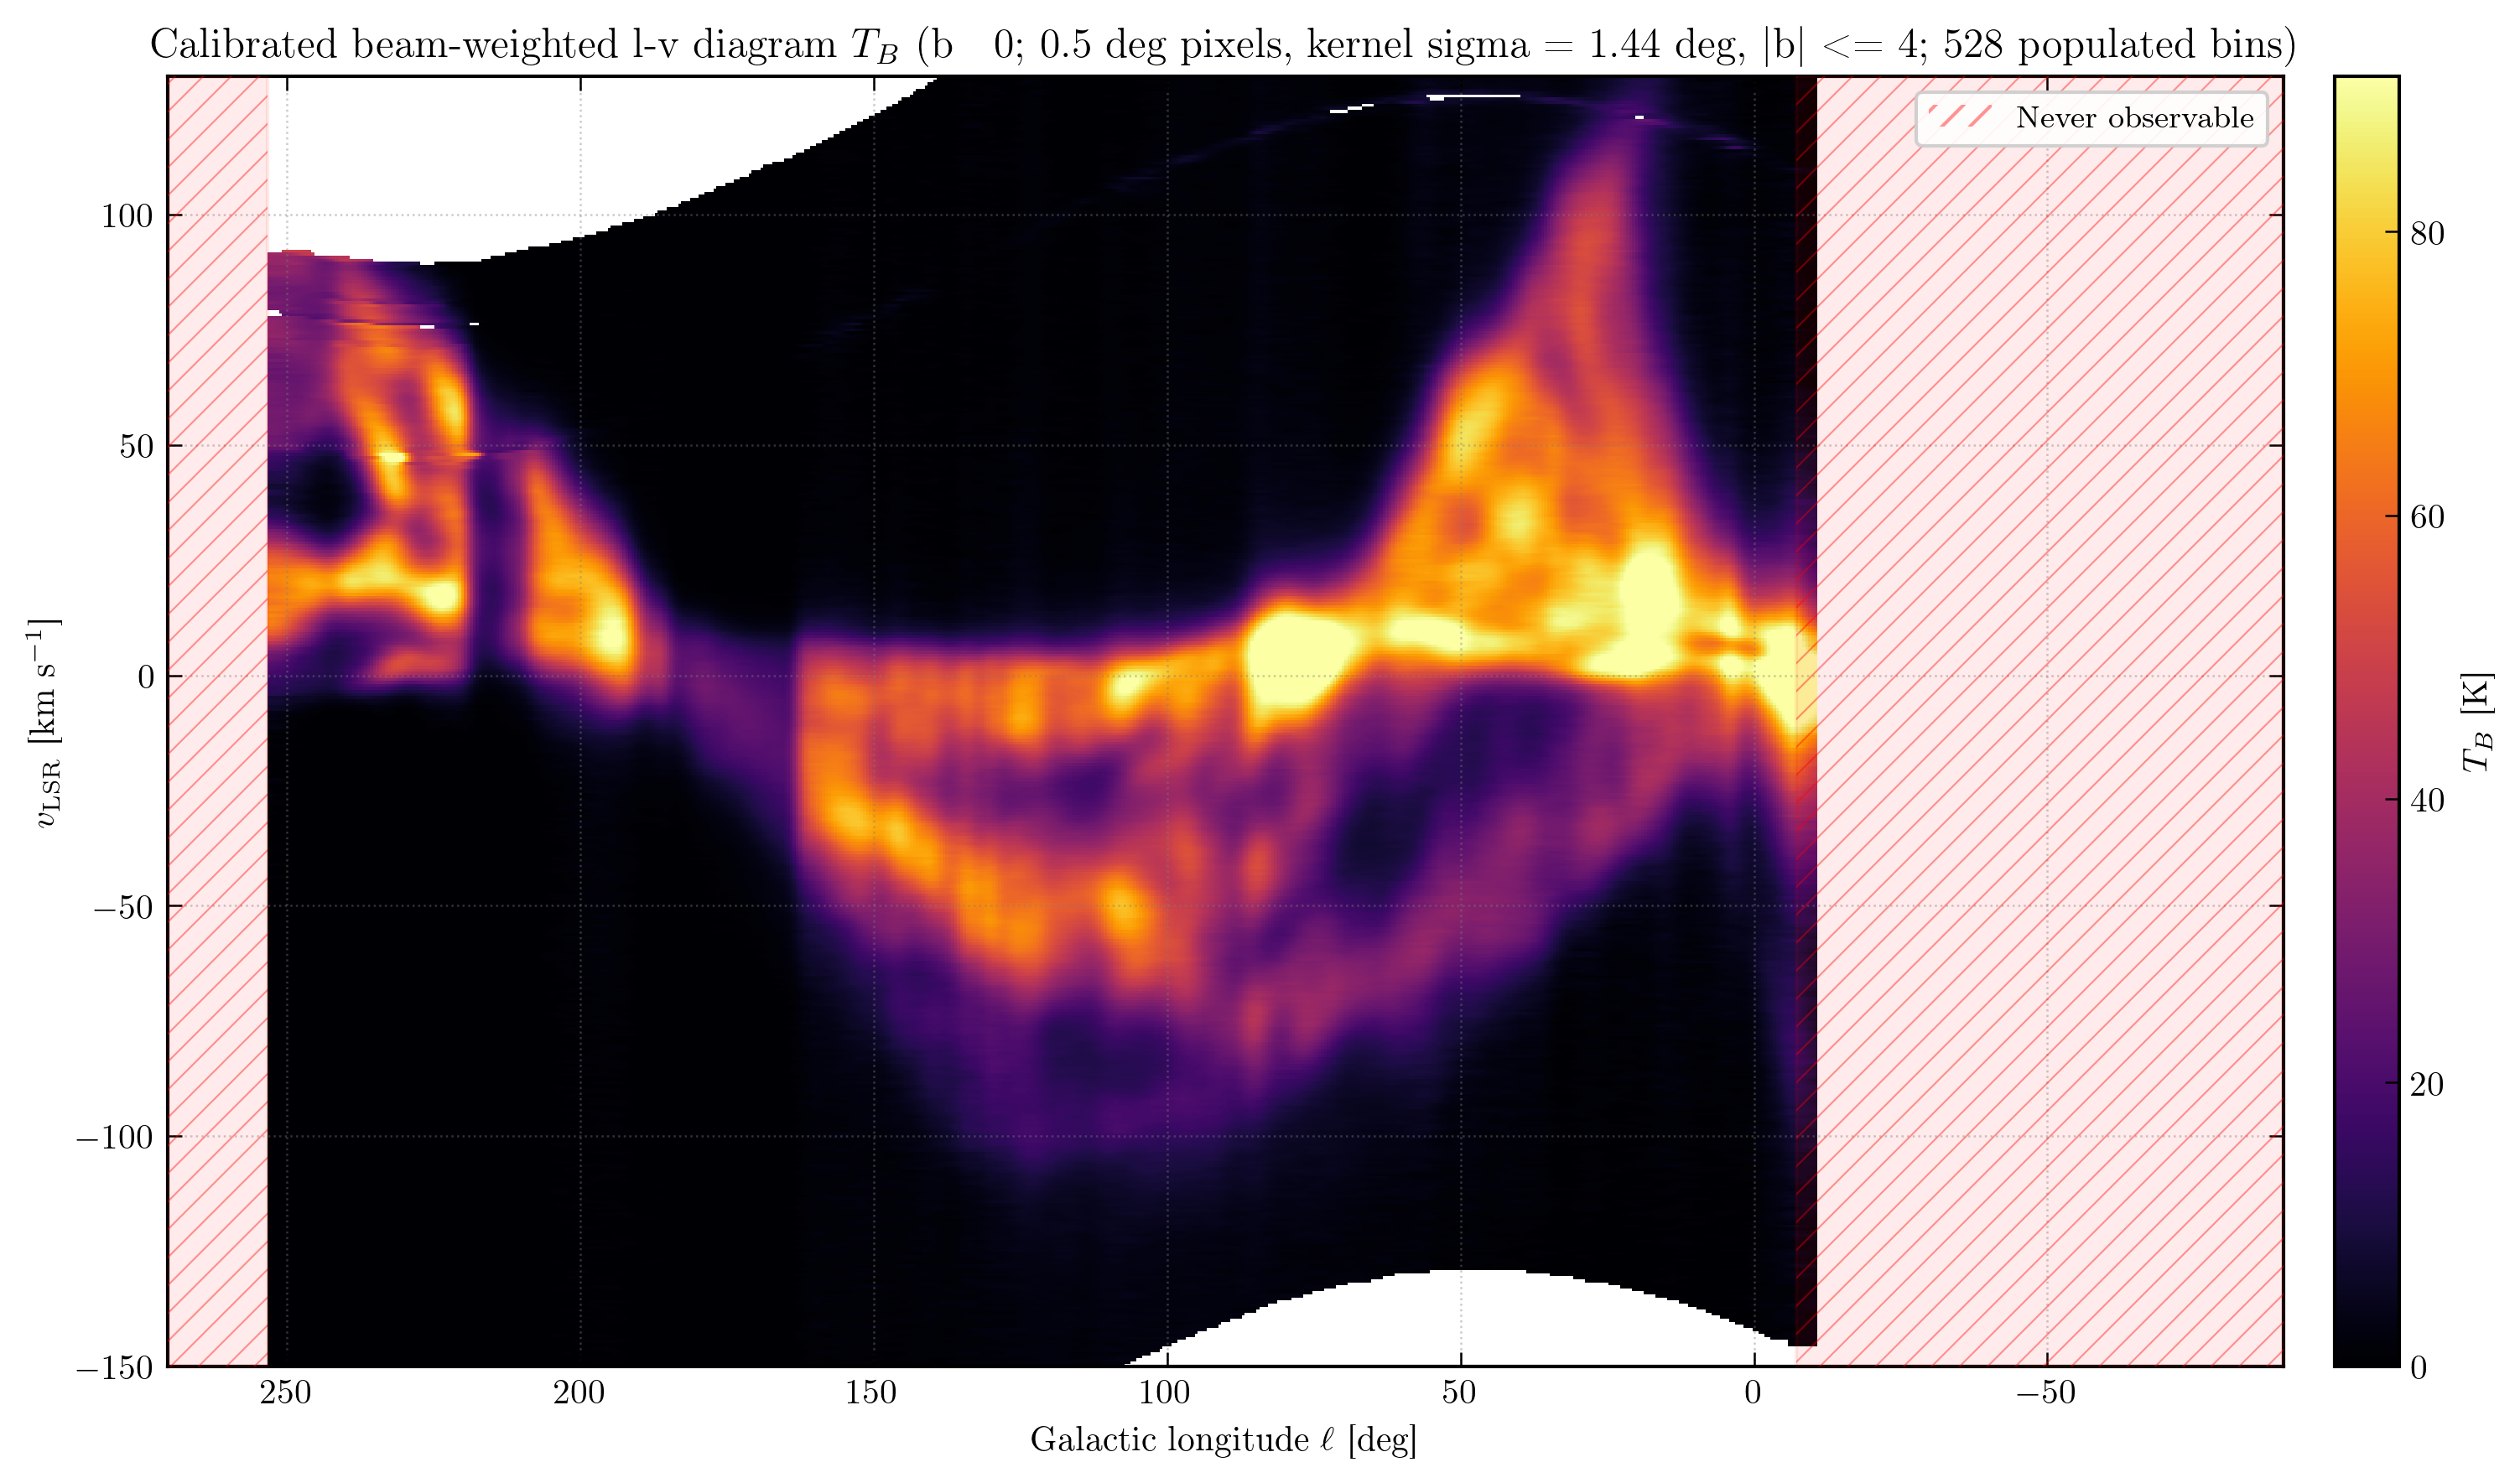

In [22]:
excluded = {(c['l'], c['b']) for c in cells_insufficient_pairs}

strip = compute_lv_strip(
    cell_combined, excluded,
    b_max_deg=B_MAX_DEG,
    dl_fine_deg=LV_DL_FINE,
    hpbw_deg=HPBW_DEG,
    cutoff_hpbw=CUTOFF_HPBW,
    spectrum_key='T_B',
)

fig, ax = plot_lv_strip(
    strip['l_fine'], v_lsr_overlap, strip['lv_image'],
    title=(f"Calibrated beam-weighted l-v diagram $T_B$ (b ~ 0; "
           f"{LV_DL_FINE} deg pixels, kernel sigma = {strip['sigma_deg']:.2f} deg, "
           f"|b| <= {B_MAX_DEG:.0f}; {strip['n_populated']} populated bins)"),
    cbar_label=r'$T_B$ [K]',
)
plt.show()

## Persist data products

`artifacts/scan_data_products.pkl` carries the per-cell calibrated
Stokes-I and per-pol $T_B$ spectra plus the two gridded products. It
is intended as the input for downstream science notebooks (rotation
curve, position-velocity analyses) without re-running calibration.

In [23]:
products = {
    'v_lsr_overlap': v_lsr_overlap,
    'dv_kms': dv_kms,
    'cells': {
        (gl, gb): {
            'T_B':                entry['T_B'],
            'T_B_pol0':           entry['T_B_pol0'],
            'T_B_pol1':           entry['T_B_pol1'],
            'T_sys_pol0':         entry.get('T_sys_pol0', np.nan),
            'T_sys_pol1':         entry.get('T_sys_pol1', np.nan),
            'pol_demoted':        entry.get('pol_demoted'),
            'pol_disagree_frac':  entry.get('pol_disagree_frac', np.nan),
            'extrapolated':       bool(entry.get('extrapolated', False)),
        }
        for (gl, gb), entry in cell_combined.items()
    },
    'W': {
        'gl':  gl_arr,
        'gb':  gb_arr,
        'W':   W_TB,
        'valid': valid,
    },
    'lv_strip': {
        'l_fine':    strip['l_fine'],
        'v_lsr':     v_lsr_overlap,
        'lv_image':  strip['lv_image'],
        'sigma_deg': strip['sigma_deg'],
        'b_max_deg': B_MAX_DEG,
        'dl_fine_deg': LV_DL_FINE,
    },
    'moll_center_l': MOLL_CENTER_L,
    'hpbw_deg': HPBW_DEG,
    'pixel_deg': PIXEL_DEG,
    'cutoff_hpbw': CUTOFF_HPBW,
    'nh_to_tbkms': NH_TO_TBKMS,
    'tcal_fit_window': (T_MIN_FIT, T_MAX_FIT),
    'tcal_n_harmonics': N_HARM,
    'pol_disagree_frac_threshold': POL_DISAGREE_FRAC,
}

with open(PRODUCTS_PATH, 'wb') as f:
    pickle.dump(products, f)
print(f'Wrote {PRODUCTS_PATH} '
      f'({PRODUCTS_PATH.stat().st_size/1e6:.2f} MB) -- '
      f'{len(products["cells"])} cells, '
      f'{int(valid.sum())} valid in W map, '
      f'{strip["n_populated"]} populated l-v columns')

Wrote artifacts/scan_data_products.pkl (31.76 MB) -- 2652 cells, 2652 valid in W map, 528 populated l-v columns
